# 1. Importando bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import cross_validate, StratifiedKFold

from sklearn.pipeline import Pipeline

import sys

import joblib

# 2. Clonando el repositorio

In [2]:
!git clone -b feature/model-training https://github.com/ezeperezds/Anemia-Prediction-System.git

Cloning into 'Anemia-Prediction-System'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 93 (delta 30), reused 70 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 2.27 MiB | 12.17 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [3]:
sys.path.append('/content/Anemia-Prediction-System/')

# 3. Importando los datos

In [4]:
X_temp = pd.read_csv('/content/Anemia-Prediction-System/data/processed/X_temp.csv')
X_train = np.load('/content/Anemia-Prediction-System/data/processed/X_train.npy')
X_val = np.load('/content/Anemia-Prediction-System/data/processed/X_val.npy')

y_temp = np.load('/content/Anemia-Prediction-System/data/processed/y_temp.npy')
y_train = np.load('/content/Anemia-Prediction-System/data/processed/y_train.npy')
y_val = np.load('/content/Anemia-Prediction-System/data/processed/y_val.npy')

In [5]:
from src.preprocessing.features import FeatureSelector

In [6]:
preprocessor = joblib.load('/content/Anemia-Prediction-System/models/preprocessor_pipeline.pkl')

In [7]:
X_train.shape

(993, 8)

In [8]:
X_val.shape

(214, 8)

# 4. Definiendo la métrica del problema

**Desglosar**


Metrica/s a utilizar -> Recall por el peso que tienen los falsos negativos, F1-Score para mantener balance entre precision y recall

# 5. Modelos candidatos a evaluar

**Desglosar**

Posibles candidatos:

* LogisticRegression(Baseline)
* XGBoost
* LightGBM
* SVC
* DecisionTree
* RandomForest
* CatBoost

In [9]:
def show_metrics(model_name, y_true, y_pred):
  metrics = {
      'accuracy': round(accuracy_score(y_true, y_pred), 2),
      'precision': round(precision_score(y_true, y_pred), 2),
      'recall': round(recall_score(y_true, y_pred), 2),
      'f1-score': round(f1_score(y_true, y_pred), 2)
  }

  return f'{model_name} metrics: {metrics}'

In [10]:
def show_confusion_matrix(y_true, y_pred):
  matrix = confusion_matrix(y_true, y_pred)
  visualizer = ConfusionMatrixDisplay(matrix, display_labels=['Sin anemia', 'Con anemia'])
  return visualizer.plot()

# 6. Baseline

In [11]:
model = LogisticRegression(random_state=82, max_iter=1000, C=0.01)

model.fit(X_train, y_train)

LogisticRegression(C=0.01, max_iter=1000, random_state=82)

In [12]:
y_pred = model.predict(X_val)

## 6.1 Evaluación de metricas

In [13]:
log_metrics = show_metrics('logistic regresion', y_val, y_pred)
log_metrics

"logistic regresion metrics: {'accuracy': 0.92, 'precision': 0.9, 'recall': 0.92, 'f1-score': 0.91}"

### Matriz de confusión

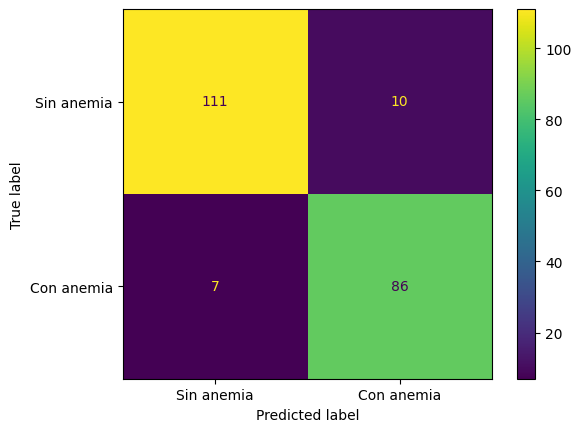

In [14]:
confusion_matrix_lr = show_confusion_matrix(y_val, y_pred)
plt.show()

## Matriz de confusión

La matriz de confusión permite analizar el desempeño del modelo más allá de las métricas agregadas, identificando los tipos de errores cometidos en la clasificación.

---

El modelo obtuvo:

* 111 verdaderos negativos, clasificando correctamente pacientes sin anemia.
* 86 verdaderos positivos, identificando correctamente pacientes con anemia.
* 10 falsos positivos, donde pacientes sin anemia fueron clasificados como positivos.
* 7 falsos negativos, donde pacientes con anemia no fueron detectados.
---

En términos clínicos, el modelo presenta un buen desempeño en la detección de casos positivos, obteniendo un recall aproximado del 92.5%. Sin embargo, existen 7 casos de anemia no identificados, por lo que en futuras iteraciones se evaluarán ajustes del modelo y selección de hiperparámetros buscando reducir los falsos negativos.

## 6.2 Validación cruzada

In [15]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=82, max_iter=1000, C=0.01))
])

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=82
)

In [17]:
scores = cross_validate(
    pipeline_lr,
    X_temp,
    y_temp,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    return_train_score=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [18]:
results = pd.DataFrame(scores)

results

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.076380,0.056392,0.925620,0.885965,0.952830,0.918182
1,0.107713,0.059729,0.938017,0.959596,0.896226,0.926829
2,0.067837,0.075618,0.921162,0.864407,0.971429,0.914798
3,0.051144,0.062780,0.912863,0.868421,0.942857,0.904110
4,0.050731,0.052901,0.937759,0.932692,0.923810,0.928230


In [19]:
metrics = {
    "accuracy":
        scores["test_accuracy"].mean().round(4),

    "precision":
        scores["test_precision"].mean().round(4),

    "recall":
        scores["test_recall"].mean().round(4),

    "f1":
        scores["test_f1"].mean().round(4)
}


metrics

{'accuracy': np.float64(0.9271),
 'precision': np.float64(0.9022),
 'recall': np.float64(0.9374),
 'f1': np.float64(0.9184)}

In [20]:
scores['test_f1'].mean().round(4)

np.float64(0.9184)

In [21]:
scores['test_f1'].std().round(4)

np.float64(0.0088)

## Observación:

Se noto que el valor por defecto de `C` (1) en LogisticRegression() producia un modelo con un rendimiento elevado, aunque con cierta variación entre los folds de validación cruzada. Asi tambien, se noto que algunos de estos folds presentaban metricas perfectas, lo cual podria indicar que el modelo se ajustaba bastante a las caracteristicas específicas de ciertos conjuntos de datos.

Para analizar el efecto de la regularización, se evaluaron distintos valores del hiperparámetro `C`. Al reducir este valor, se incrementó la penalización aplicada a los coeficientes del modelo, reduciendo su complejidad y logrando una mayor estabilidad entre los folds.

El valor `C=0.01` presentó un mejor equilibrio entre capacidad predictiva y generalización, manteniendo valores altos de recall y F1-score, pero reduciendo la variabilidad observada con el valor inicial.

Valores menores como `C=0.001` aumentaron demasiado la regularización, provocando una disminución significativa del recall, indicando que el modelo comenzó a perder capacidad para identificar correctamente los casos positivos.

# 7. DecisionTree

In [22]:
tree_model = DecisionTreeClassifier(random_state=82)